# ClonalOrigin model and simulation-based inference

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sbi.utils.torchutils import BoxUniform
from sbi.inference import NPE_C, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Observation data, simulator and prior

**Clonal tree:**
* `tree = ClonalTree(n=15)`

**Simulate observed data**

Set the true parameters as
* $\rho_s = 0.02$,
* $\delta = 300$,
* $\theta_s = 0.05$.

**Define prior distribution**

We set the prior to be uniform with range:
* $[0, 0.2]$ for $\rho_s$,
* $[1, 500]$ for $\delta$,
* $[0, 0.2]$ for $\theta_s$.

In [2]:
prior = BoxUniform(
    low=torch.tensor([0.0, 1.0, 0.0], device=torch_device),
    high=torch.tensor([0.2, 500.0, 0.2], device=torch_device), 
    device=torch_device
)

## Visualisation

In [3]:
x_mat = np.loadtxt('../data/ClonalOrigin/x_mat.csv', delimiter=",", skiprows=1)
x_mat.shape

(200, 3)

In [4]:
theta_site_mat = np.loadtxt('../data/ClonalOrigin/theta_site_mat.csv', delimiter=",", skiprows=1)
rho_site_mat = np.loadtxt('../data/ClonalOrigin/rho_site_mat.csv', delimiter=",", skiprows=1)
delta_mat = np.loadtxt('../data/ClonalOrigin/delta_mat.csv', delimiter=",", skiprows=1)
theta_site_mat.shape, rho_site_mat.shape, delta_mat.shape

((200, 7), (200, 7), (200, 7))

In [5]:
x_mat = np.loadtxt('../data/ClonalOrigin/x_mat_python.csv', delimiter=",")
x_mat.shape

(200, 3)

In [6]:
theta_site_mat = np.loadtxt('../data/ClonalOrigin/theta_site_python.csv', delimiter=",")
rho_site_mat = np.loadtxt('../data/ClonalOrigin/rho_site_python.csv', delimiter=",")
delta_mat = np.loadtxt('../data/ClonalOrigin/delta_python.csv', delimiter=",")
theta_site_mat.shape, rho_site_mat.shape, delta_mat.shape

((200, 7), (200, 7), (200, 7))

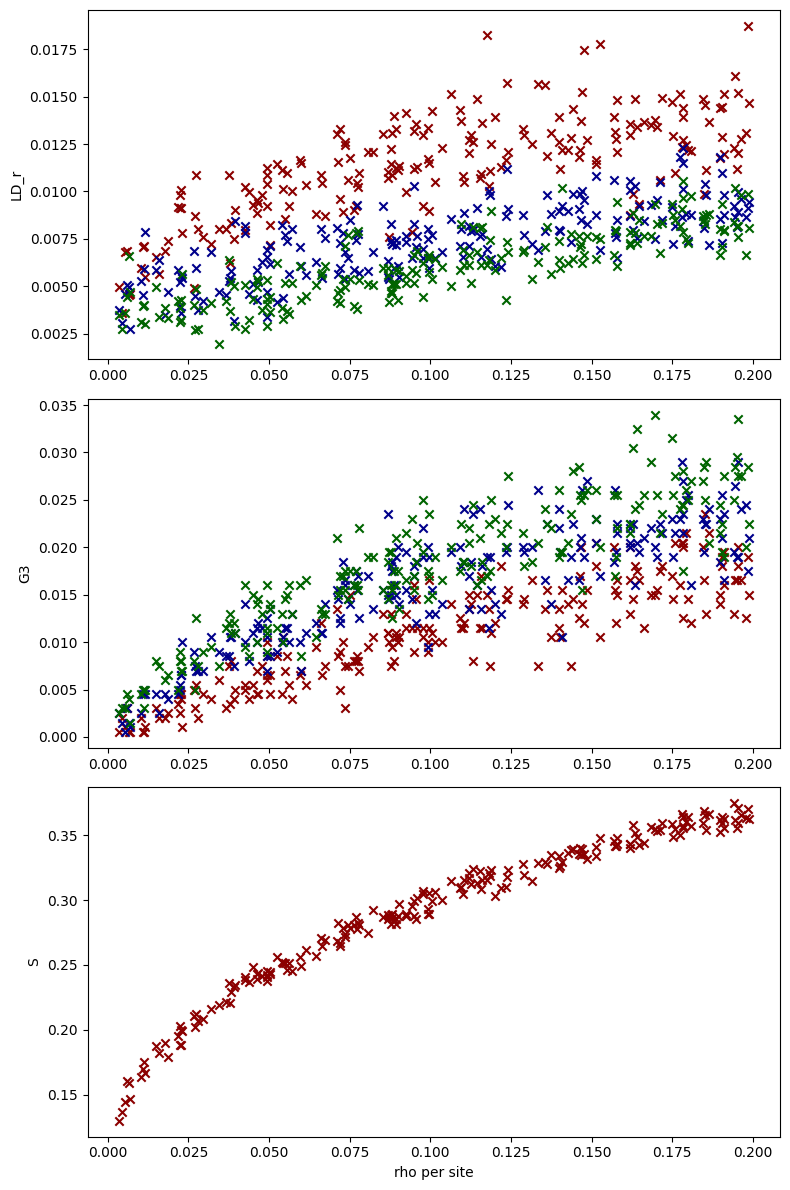

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

axs[0].scatter(x_mat[:, 0], rho_site_mat[:, 0], marker='x', color='darkred')
axs[0].scatter(x_mat[:, 0], rho_site_mat[:, 1], marker='x', color='darkblue')
axs[0].scatter(x_mat[:, 0], rho_site_mat[:, 2], marker='x', color='darkgreen')
axs[0].set_ylabel('LD_r')

axs[1].scatter(x_mat[:, 0], rho_site_mat[:, 3], marker='x', color='darkred')
axs[1].scatter(x_mat[:, 0], rho_site_mat[:, 4], marker='x', color='darkblue')
axs[1].scatter(x_mat[:, 0], rho_site_mat[:, 5], marker='x', color='darkgreen')
axs[1].set_ylabel('G3')

axs[2].scatter(x_mat[:, 0], rho_site_mat[:, 6], marker='x', color='darkred')
axs[2].set_xlabel('rho per site')
axs[2].set_ylabel('S')

plt.tight_layout()
plt.show()

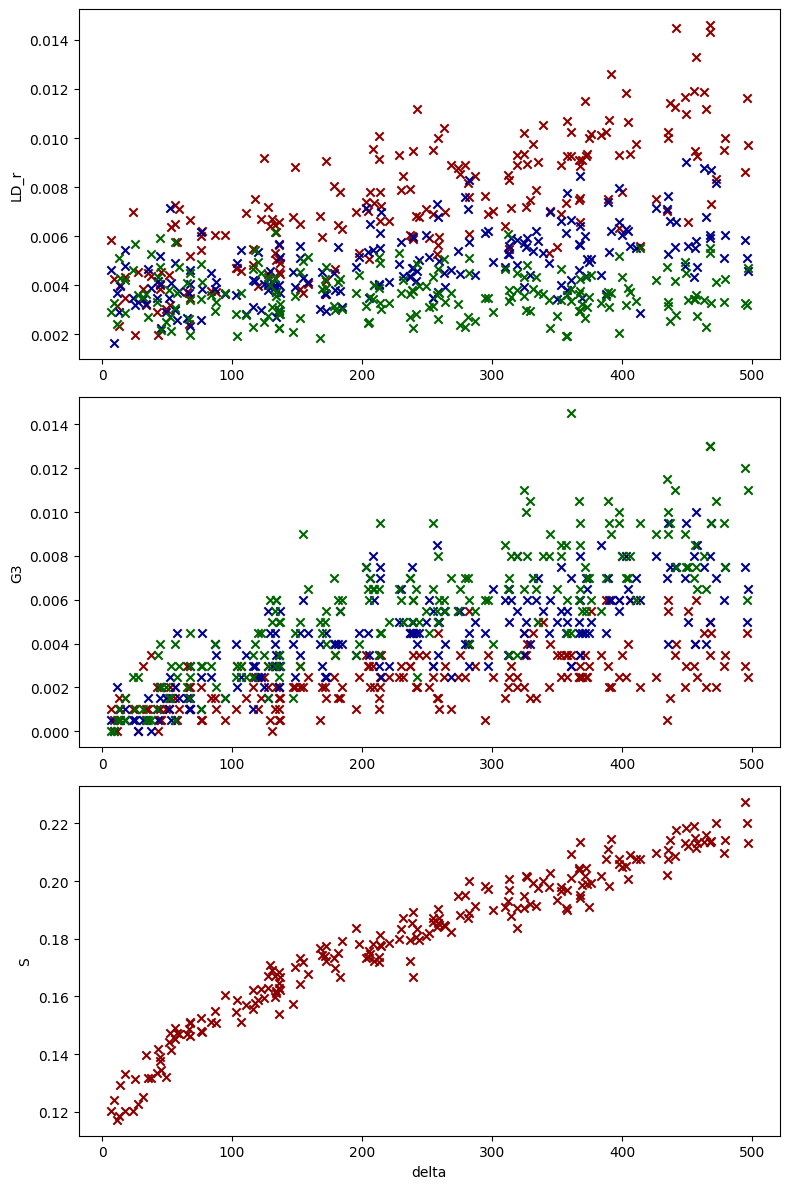

In [8]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

axs[0].scatter(x_mat[:, 1], delta_mat[:, 0], marker='x', color='darkred')
axs[0].scatter(x_mat[:, 1], delta_mat[:, 1], marker='x', color='darkblue')
axs[0].scatter(x_mat[:, 1], delta_mat[:, 2], marker='x', color='darkgreen')
axs[0].set_ylabel('LD_r')

axs[1].scatter(x_mat[:, 1], delta_mat[:, 3], marker='x', color='darkred')
axs[1].scatter(x_mat[:, 1], delta_mat[:, 4], marker='x', color='darkblue')
axs[1].scatter(x_mat[:, 1], delta_mat[:, 5], marker='x', color='darkgreen')
axs[1].set_ylabel('G3')

axs[2].scatter(x_mat[:, 1], delta_mat[:, 6], marker='x', color='darkred')
axs[2].set_xlabel('delta')
axs[2].set_ylabel('S')

plt.tight_layout()
plt.show()

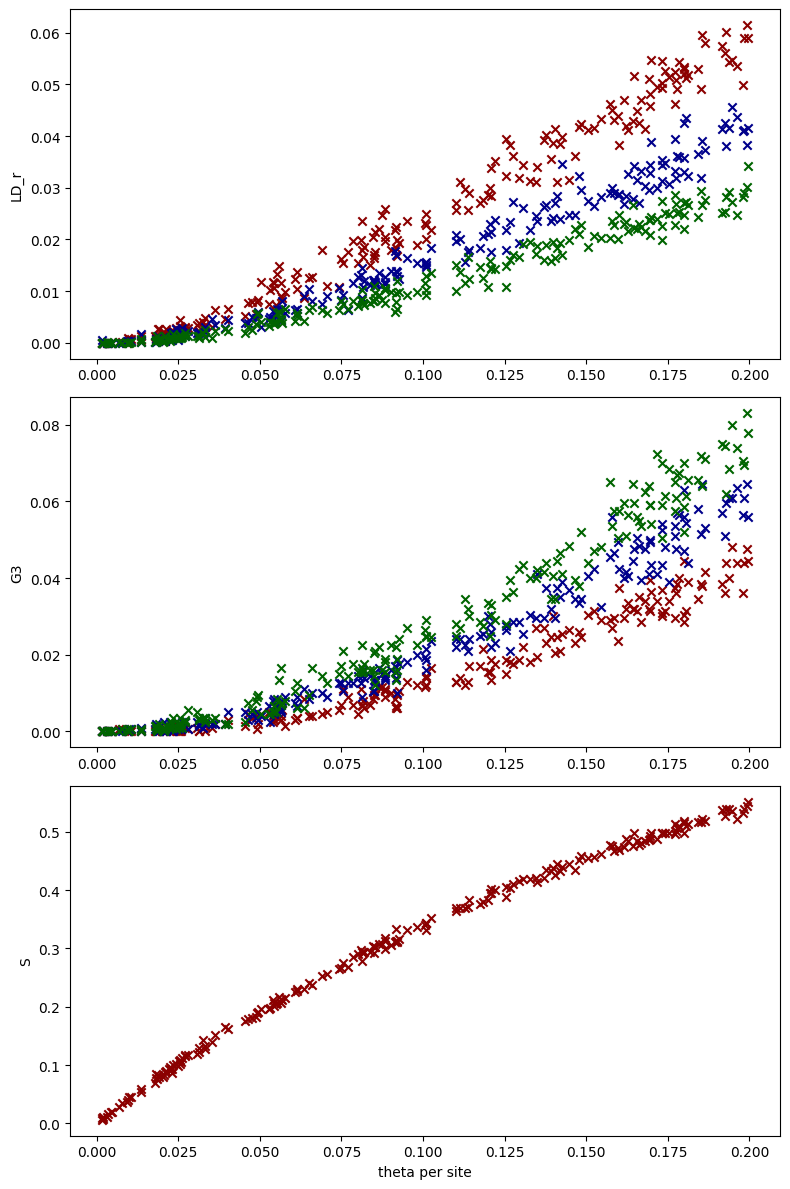

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

axs[0].scatter(x_mat[:, 2], theta_site_mat[:, 0], marker='x', color='darkred')
axs[0].scatter(x_mat[:, 2], theta_site_mat[:, 1], marker='x', color='darkblue')
axs[0].scatter(x_mat[:, 2], theta_site_mat[:, 2], marker='x', color='darkgreen')
axs[0].set_ylabel('LD_r')

axs[1].scatter(x_mat[:, 2], theta_site_mat[:, 3], marker='x', color='darkred')
axs[1].scatter(x_mat[:, 2], theta_site_mat[:, 4], marker='x', color='darkblue')
axs[1].scatter(x_mat[:, 2], theta_site_mat[:, 5], marker='x', color='darkgreen')
axs[1].set_ylabel('G3')

axs[2].scatter(x_mat[:, 2], theta_site_mat[:, 6], marker='x', color='darkred')
axs[2].set_xlabel('theta per site')
axs[2].set_ylabel('S')

plt.tight_layout()
plt.show()

## NPE-C

### Load simulated dataset

In [10]:
x_o = np.loadtxt('../data/ClonalOrigin/x_o_10000.csv', delimiter=",")
x_o = torch.tensor(x_o, device=torch_device)
x_o = x_o.to(torch.float32)
x_o = x_o.flatten()
x_o_numpy = x_o.cpu().numpy()
x_o

tensor([0.0076, 0.0062, 0.0045, 0.0015, 0.0065, 0.0085, 0.1895])

In [11]:
theta = np.loadtxt('../data/ClonalOrigin/theta_10000.csv', delimiter=",")
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()
theta

tensor([[1.4161e-01, 5.7735e+01, 1.0255e-01],
        [3.7611e-02, 1.2744e+02, 1.7380e-01],
        [1.5440e-01, 2.8293e+02, 1.7661e-01],
        ...,
        [1.0442e-01, 2.7950e+02, 6.4138e-02],
        [2.7635e-02, 1.8600e+02, 1.8453e-02],
        [2.0037e-02, 4.1082e+02, 5.1941e-02]])

In [12]:
x = np.loadtxt('../data/ClonalOrigin/x_10000.csv', delimiter=",")
x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()
x

tensor([[1.6565e-02, 1.1862e-02, 1.0331e-02,  ..., 3.3000e-02, 3.4000e-02,
         3.7500e-01],
        [3.4378e-02, 2.6717e-02, 2.0005e-02,  ..., 4.9000e-02, 4.7500e-02,
         4.9150e-01],
        [6.5619e-02, 4.2503e-02, 3.7243e-02,  ..., 1.8800e-01, 2.0100e-01,
         7.3617e-01],
        ...,
        [1.6074e-02, 1.1019e-02, 8.0735e-03,  ..., 2.5500e-02, 2.7500e-02,
         3.6100e-01],
        [1.4979e-03, 1.9655e-03, 6.0381e-04,  ..., 1.0000e-03, 5.0000e-04,
         7.2500e-02],
        [1.3057e-02, 6.4116e-03, 3.7926e-03,  ..., 7.5000e-03, 7.0000e-03,
         2.1767e-01]])

In [13]:
x_o.shape, theta.shape, x.shape

(torch.Size([7]), torch.Size([10000, 3]), torch.Size([10000, 7]))

In [14]:
x_o.dtype, theta.dtype, x.dtype

(torch.float32, torch.float32, torch.float32)

### Run NPE

In [16]:
prior = BoxUniform(
    low=torch.tensor([0.0, 1.0, 0.0], device=torch_device),
    high=torch.tensor([0.2, 500.0, 0.2], device=torch_device), 
    device=torch_device
)

In [17]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [18]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=100, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator).set_default_x(x_o)

 Training neural network. Epochs trained: 101

In [20]:
theta_trained = posterior.sample((num_posterior_samples,), x=x_o)
theta_trained_numpy = theta_trained.cpu().numpy()

1080it [00:00, 7499.77it/s]                         


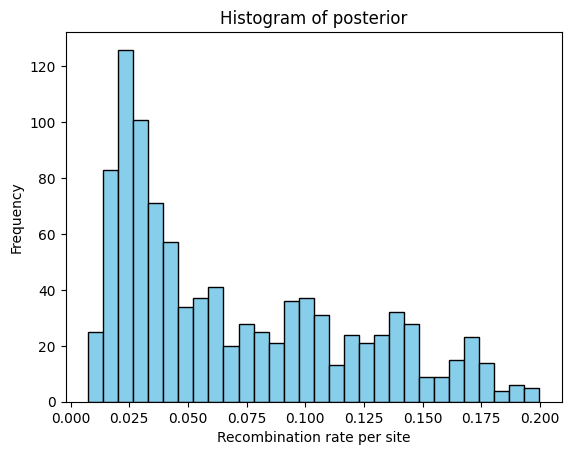

In [21]:
plt.hist(theta_trained_numpy[:, 0], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Recombination rate per site')
plt.ylabel('Frequency')
plt.title('Histogram of posterior')
plt.show()

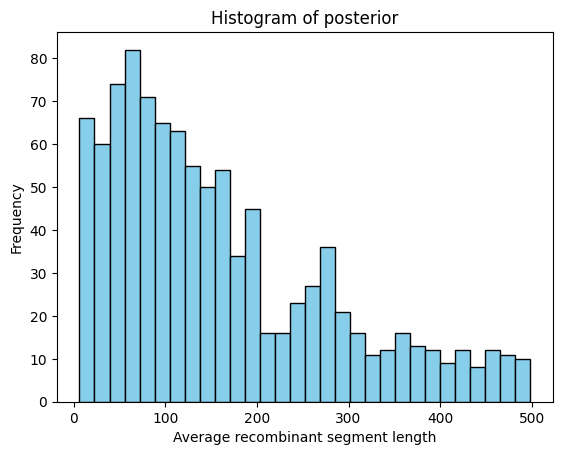

In [22]:
plt.hist(theta_trained_numpy[:, 1], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Average recombinant segment length')
plt.ylabel('Frequency')
plt.title('Histogram of posterior')
plt.show()

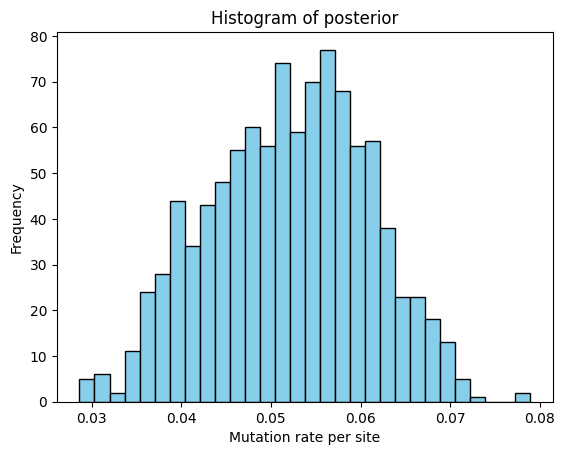

In [23]:
plt.hist(theta_trained_numpy[:, 2], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Mutation rate per site')
plt.ylabel('Frequency')
plt.title('Histogram of posterior')
plt.show()